<a href="https://colab.research.google.com/github/MarriRohan/6G-RL-Edge-Caching/blob/main/6G%20RL%20Edge%20Caching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random

In [ ]:
class FeRANEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.num_contents = 100
        self.cache_size = 20
        self.num_users = 10

        # Zipf popularity
        self.popularity = np.random.zipf(1.2, self.num_contents)
        self.popularity = self.popularity / self.popularity.sum()

        # Users
        self.user_locations = np.random.randint(
            0, 5, self.num_users
        )

        # Cache with TTL
        self.cache = {}

        self.action_space = spaces.Discrete(
            self.num_contents
        )

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.num_contents * 2,),
            dtype=np.float32
        )

    def get_state(self):

        cache_state = np.zeros(self.num_contents)

        for c in self.cache:
            cache_state[c] = 1

        return np.concatenate([
            self.popularity,
            cache_state
        ])

    def reset(self, seed=None, options=None):

        self.cache = {}

        return self.get_state(), {}

    def step(self, action):

        # Cache selected content
        self.cache[action] = 10

        # TTL update
        expired = []

        for c in self.cache:

            self.cache[c] -= 1

            if self.cache[c] <= 0:
                expired.append(c)

        for c in expired:
            del self.cache[c]

        # User mobility
        self.user_locations += np.random.randint(
            -1,
            2,
            self.num_users
        )

        # Request generation
        requested_content = np.random.choice(
            self.num_contents,
            p=self.popularity
        )

        cache_hit = requested_content in self.cache

        if cache_hit:
            delay = 1
            bandwidth = 0
            cloud_downloads = 0
            hit_ratio = 1

        else:
            delay = 5
            bandwidth = 1
            cloud_downloads = 1
            hit_ratio = 0

        cache_energy = len(self.cache) * 0.01

        transport_energy = (
            cloud_downloads * 0.05
        )

        total_energy = (
            cache_energy +
            transport_energy
        )

        reward = (
            5 * hit_ratio
            - delay
            - total_energy
            - bandwidth
        )

        terminated = False

        return (
            self.get_state(),
            reward,
            terminated,
            False,
            {}
        )

In [ ]:
env = FeRANEnv()

state, _ = env.reset()

for i in range(10):

    action = env.action_space.sample()

    state, reward, done, _, _ = env.step(action)

    print(
        f"Step={i}, Reward={reward:.2f}"
    )

Step=0, Reward=-6.06
Step=1, Reward=-6.07
Step=2, Reward=-6.08
Step=3, Reward=-6.09
Step=4, Reward=-6.10
Step=5, Reward=-6.11
Step=6, Reward=-6.12
Step=7, Reward=-6.13
Step=8, Reward=-6.14
Step=9, Reward=-6.14


DQN Train

In [ ]:
!pip install stable-baselines3

In [ ]:
from stable_baselines3 import DQN

env = FeRANEnv()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

model.learn(total_timesteps=20000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt

class FeRANEnv(gym.Env):

    def __init__(self):

        super().__init__()

        self.num_contents = 100
        self.cache_size = 20
        self.num_users = 10

        self.action_space = spaces.Discrete(
            self.num_contents
        )

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.num_contents * 2,),
            dtype=np.float32
        )

        self.reset()

    def get_state(self):

        cache_state = np.zeros(
            self.num_contents
        )

        for c in self.cache:
            cache_state[c] = 1

        return np.concatenate([
            self.popularity,
            cache_state
        ]).astype(np.float32)

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        # Zipf popularity
        self.popularity = np.random.zipf(
            1.2,
            self.num_contents
        )

        self.popularity = (
            self.popularity /
            self.popularity.sum()
        )

        # user locations
        self.user_locations = np.random.randint(
            0,
            5,
            self.num_users
        )

        # cache with ttl
        self.cache = {}

        # metrics
        self.hits = 0
        self.requests = 0

        self.total_delay = 0
        self.total_energy = 0
        self.total_bandwidth = 0

        return self.get_state(), {}

    def step(self, action):
        def step(self, action):
          if isinstance(action, np.ndarray):
            action = int(action.item())

          self.cache[action] = 10

        # add content to cache
        self.cache[action] = 10

        # cache size control
        if len(self.cache) > self.cache_size:

            oldest = list(
                self.cache.keys()
            )[0]

            del self.cache[oldest]

        # ttl update
        expired = []

        for content in self.cache:

            self.cache[content] -= 1

            if self.cache[content] <= 0:
                expired.append(content)

        for content in expired:
            del self.cache[content]

        # user mobility
        self.user_locations += np.random.randint(
            -1,
            2,
            self.num_users
        )

        # request generation
        requested_content = np.random.choice(
            self.num_contents,
            p=self.popularity
        )

        self.requests += 1

        cache_hit = (
            requested_content
            in self.cache
        )

        if cache_hit:

            self.hits += 1

            delay = 1
            bandwidth = 0
            cloud_downloads = 0

        else:

            delay = 5
            bandwidth = 1
            cloud_downloads = 1

        hit_ratio = (
            self.hits /
            self.requests
        )

        cache_energy = (
            len(self.cache) * 0.01
        )

        transport_energy = (
            cloud_downloads * 0.05
        )

        total_energy = (
            cache_energy +
            transport_energy
        )

        self.total_delay += delay
        self.total_energy += total_energy
        self.total_bandwidth += bandwidth

        reward = (
            5 * hit_ratio
            - delay
            - total_energy
            - bandwidth
        )

        terminated = False
        truncated = False

        info = {
            "hit_ratio": hit_ratio,
            "delay": delay,
            "energy": total_energy,
            "bandwidth": bandwidth
        }

        return (
            self.get_state(),
            reward,
            terminated,
            truncated,
            info
        )

In [ ]:
!pip install stable-baselines3 -q

from stable_baselines3 import DQN

env = FeRANEnv()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

model.learn(
    total_timesteps=20000
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
from stable_baselines3 import DQN

In [ ]:
print(env.requests)

20000


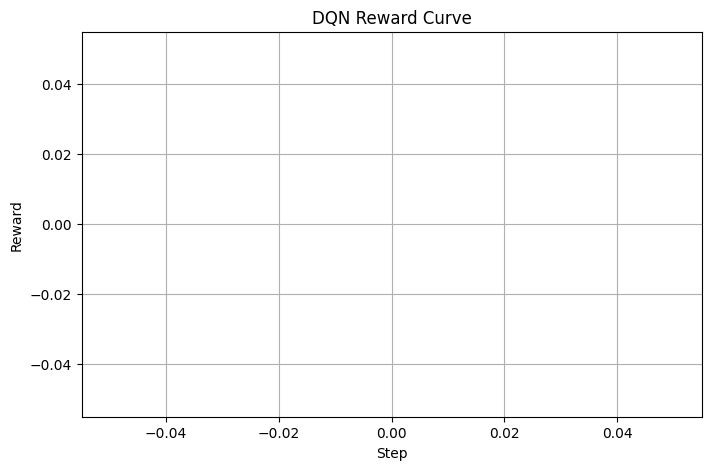

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(rewards)
plt.xlabel("Step")
plt.ylabel("Reward")
plt.title("DQN Reward Curve")
plt.grid(True)
plt.show()